In [1]:
import pandas as pd

student_df = pd.read_csv('/content/Student_Performance.csv')

print("Dataset loaded successfully!")
print("Rows and columns:", student_df.shape)

student_df.head()

Dataset loaded successfully!
Rows and columns: (10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [2]:
print("Dataset Information:")
student_df.info()

print("\nMissing Values:")
print(student_df.isnull().sum())

print("\nStatistical Summary:")
display(student_df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB

Missing Values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Statistical Summary:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [3]:
print("Column Names:")

for column in student_df.columns:
    print(column)

Column Names:
Hours Studied
Previous Scores
Extracurricular Activities
Sleep Hours
Sample Question Papers Practiced
Performance Index


In [4]:
student_df['Extracurricular Activities'] = student_df['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

student_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [5]:
X = student_df.drop('Performance Index', axis=1)
y = student_df['Performance Index']

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5



Target (y):


,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully.")

Features standardized successfully.


In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [9]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_predictions = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [10]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

lasso_predictions = lasso_model.predict(X_test_scaled)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [11]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2


linear_results = evaluate_model(y_test, linear_predictions)
ridge_results = evaluate_model(y_test, ridge_predictions)
lasso_results = evaluate_model(y_test, lasso_predictions)

print("Evaluation completed successfully.")

Evaluation completed successfully.


In [12]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],

    'MAE': [
        linear_results[0],
        ridge_results[0],
        lasso_results[0]
    ],

    'MSE': [
        linear_results[1],
        ridge_results[1],
        lasso_results[1]
    ],

    'RMSE': [
        linear_results[2],
        ridge_results[2],
        lasso_results[2]
    ],

    'R²': [
        linear_results[3],
        ridge_results[3],
        lasso_results[3]
    ]
})

results.round(4)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,1.6111,4.0826,2.0206,0.9890
1,Ridge Regression,1.6112,4.0832,2.0207,0.9890
2,Lasso Regression,1.6267,4.1753,2.0434,0.9887


In [13]:
coefficient_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear Regression': linear_model.coef_,
    'Ridge Regression': ridge_model.coef_,
    'Lasso Regression': lasso_model.coef_
})

coefficient_comparison.round(4)

,Feature,Linear Regression,Ridge Regression,Lasso Regression
0,Hours Studied,7.4013,7.4004,7.3027
1,Previous Scores,17.6373,17.6351,17.5375
2,Extracurricular Activities,0.3043,0.3043,0.2027
3,Sleep Hours,0.8100,0.8099,0.7087
4,Sample Question Papers Practiced,0.5488,0.5488,0.4512


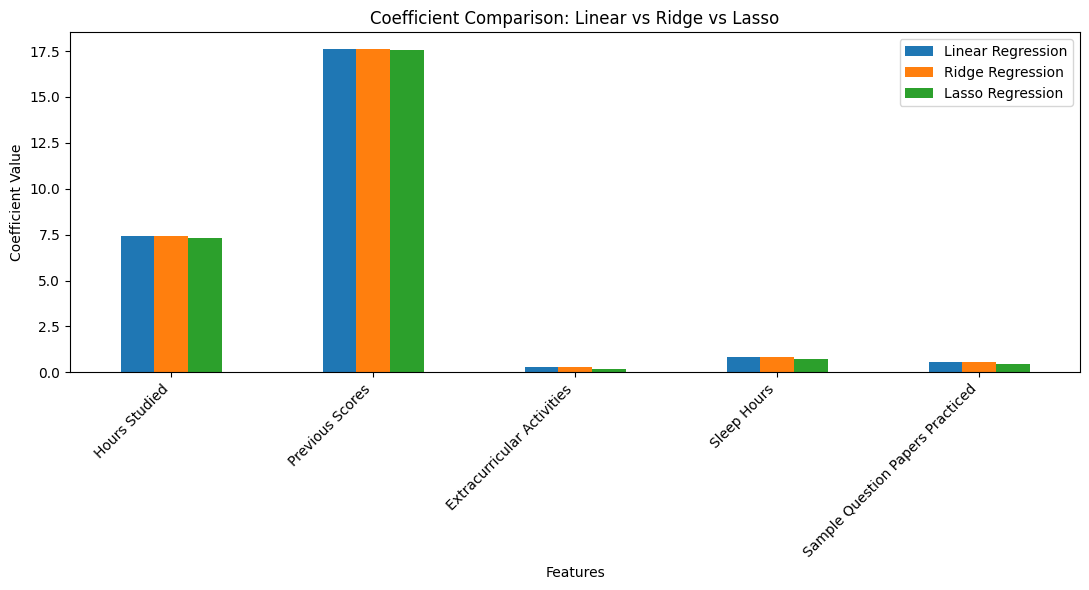

In [14]:
import matplotlib.pyplot as plt

coefficient_comparison.set_index('Feature').plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Coefficient Comparison: Linear vs Ridge vs Lasso')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [17]:
best_model = results.loc[results['R²'].idxmax()]

print("Best Model:", best_model['Model'])
print("MAE:", round(best_model['MAE'], 4))
print("MSE:", round(best_model['MSE'], 4))
print("RMSE:", round(best_model['RMSE'], 4))
print("R²:", round(best_model['R²'], 4))

Best Model: Linear Regression
MAE: 1.6111
MSE: 4.0826
RMSE: 2.0206
R²: 0.989
